##Installing Libraries

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


##Importing all Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
import joblib

##Load Dataset

In [ ]:
car_data = pd.read_csv('/content/car data.csv')
print(car_data.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


##Basic Data Exploration

In [ ]:
print(car_data.info())
print(car_data.shape)
print(car_data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None
(301, 9)
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.1000

In [ ]:
print('Missing values in each column:')
print(car_data.isnull().sum())

print('\nUnique values and their counts for categorical columns:')
for col in car_data.select_dtypes(include='object').columns:
    print(f'\nColumn: {col}')
    print(car_data[col].value_counts())

Missing values in each column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Unique values and their counts for categorical columns:

Column: Car_Name
Car_Name
city                  26
corolla altis         16
verna                 14
fortuner              11
brio                  10
                      ..
Honda Activa 125       1
Hero Hunk              1
Hero  Ignitor Disc     1
Hero  CBZ Xtreme       1
Bajaj  ct 100          1
Name: count, Length: 98, dtype: int64

Column: Fuel_Type
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Column: Selling_type
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

Column: Transmission
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


##Data Cleaning

In [ ]:
current_year = 2024 # Assuming current year for calculating car age
car_data['No_Year'] = current_year - car_data['Year']

# Drop original 'Year' and 'Car_Name' columns
car_data.drop(['Year', 'Car_Name'], axis=1, inplace=True)

# Convert categorical features to numerical using one-hot encoding
final_data = pd.get_dummies(car_data, drop_first=True)

print("Dataset after feature engineering and one-hot encoding:")
print(final_data.head())

Dataset after feature engineering and one-hot encoding:
   Selling_Price  Present_Price  Driven_kms  Owner  No_Year  Fuel_Type_Diesel  \
0           3.35           5.59       27000      0       10             False   
1           4.75           9.54       43000      0       11              True   
2           7.25           9.85        6900      0        7             False   
3           2.85           4.15        5200      0       13             False   
4           4.60           6.87       42450      0       10              True   

   Fuel_Type_Petrol  Selling_type_Individual  Transmission_Manual  
0              True                    False                 True  
1             False                    False                 True  
2              True                    False                 True  
3              True                    False                 True  
4             False                    False                 True  


##Price Distribution

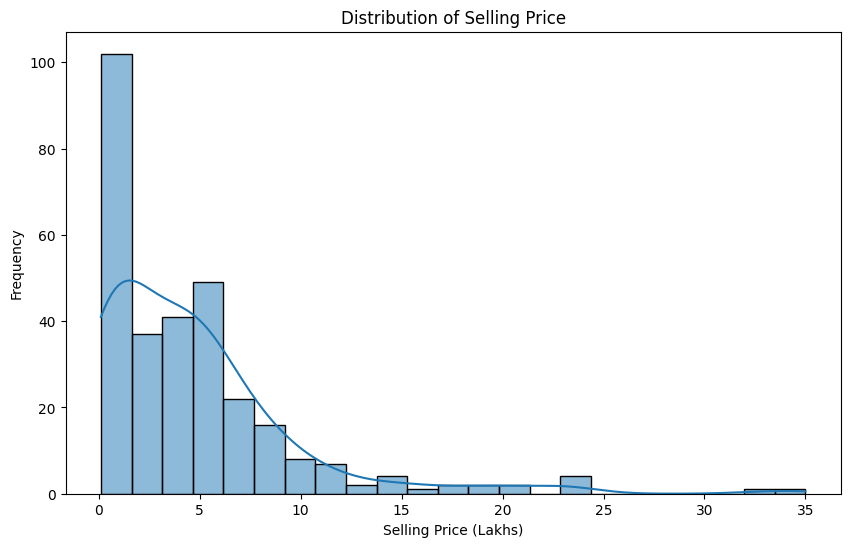

Skewness of Selling_Price: 2.49
Kurtosis of Selling_Price: 8.90


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(final_data['Selling_Price'], kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (Lakhs)')
plt.ylabel('Frequency')
plt.show()

print(f"Skewness of Selling_Price: {final_data['Selling_Price'].skew():.2f}")
print(f"Kurtosis of Selling_Price: {final_data['Selling_Price'].kurt():.2f}")

##Correlation Analysis

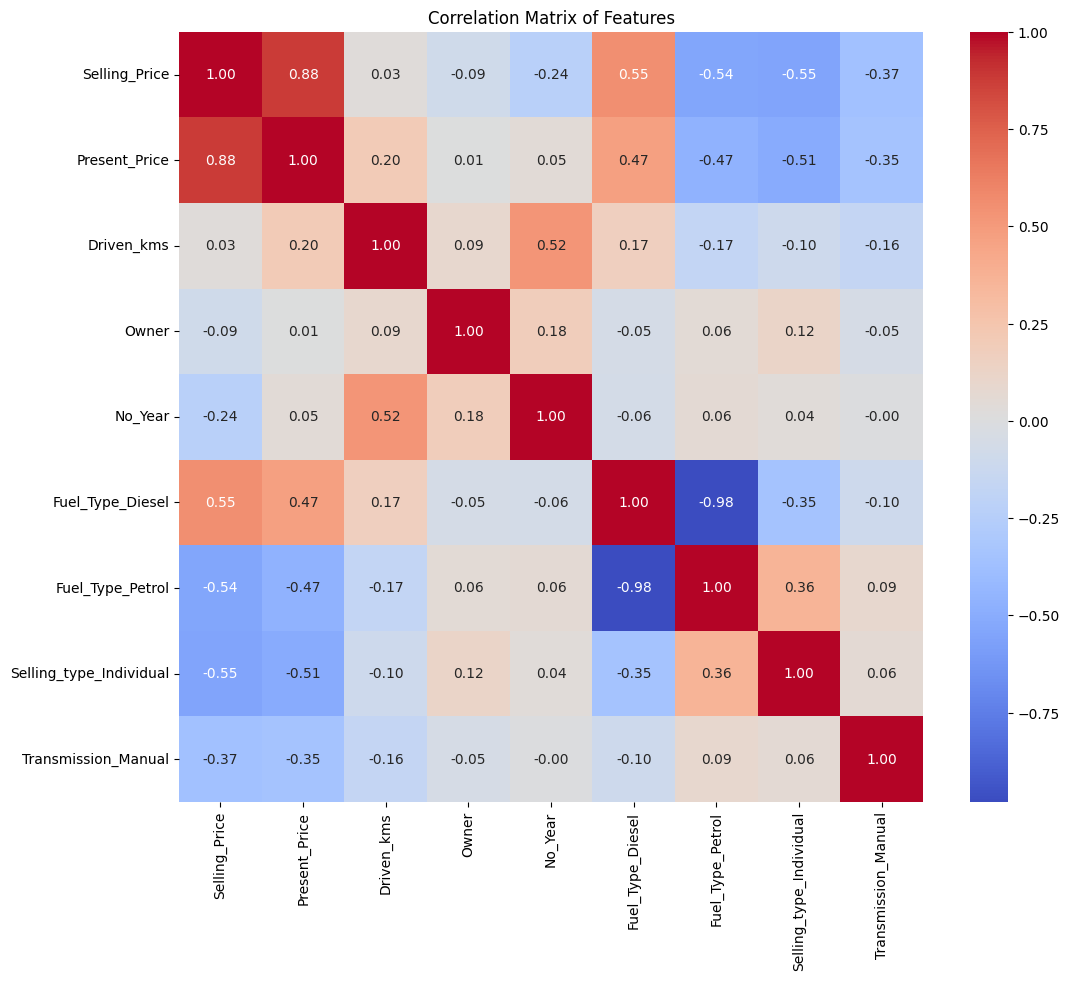

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(final_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

##Visualize Relationships

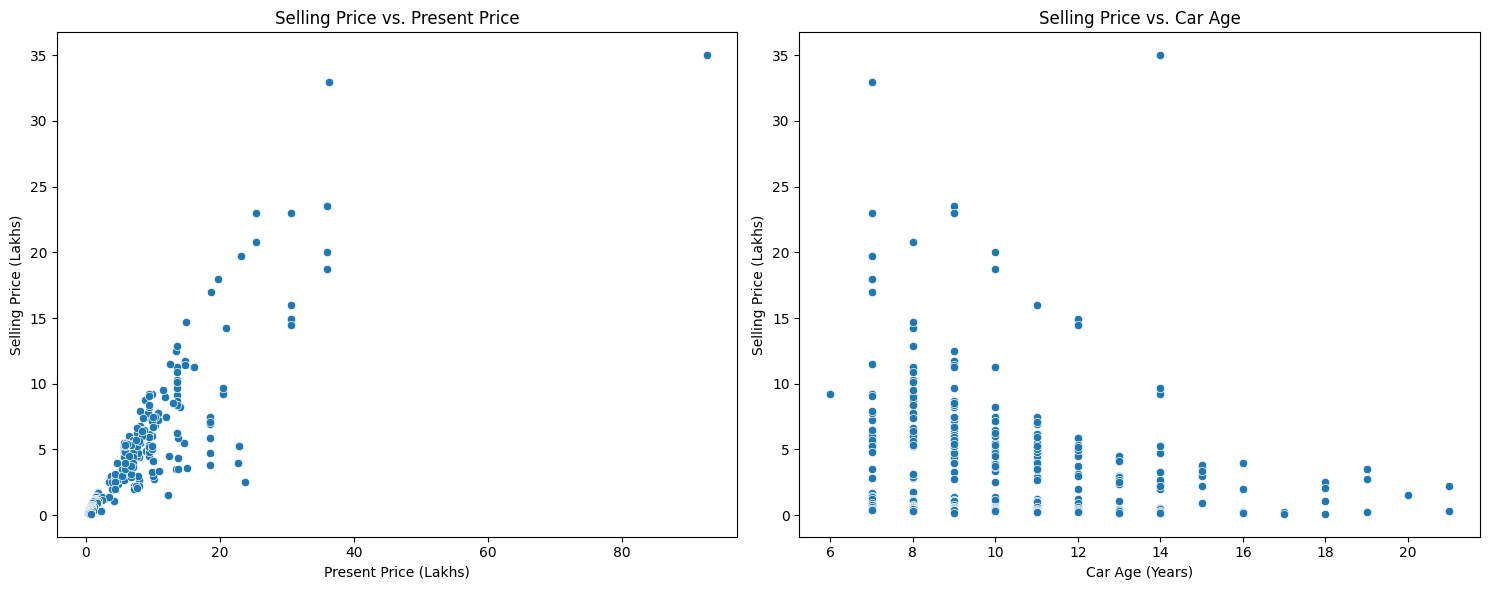

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x='Present_Price', y='Selling_Price', data=final_data)
plt.title('Selling Price vs. Present Price')
plt.xlabel('Present Price (Lakhs)')
plt.ylabel('Selling Price (Lakhs)')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(x='No_Year', y='Selling_Price', data=final_data)
plt.title('Selling Price vs. Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.show()

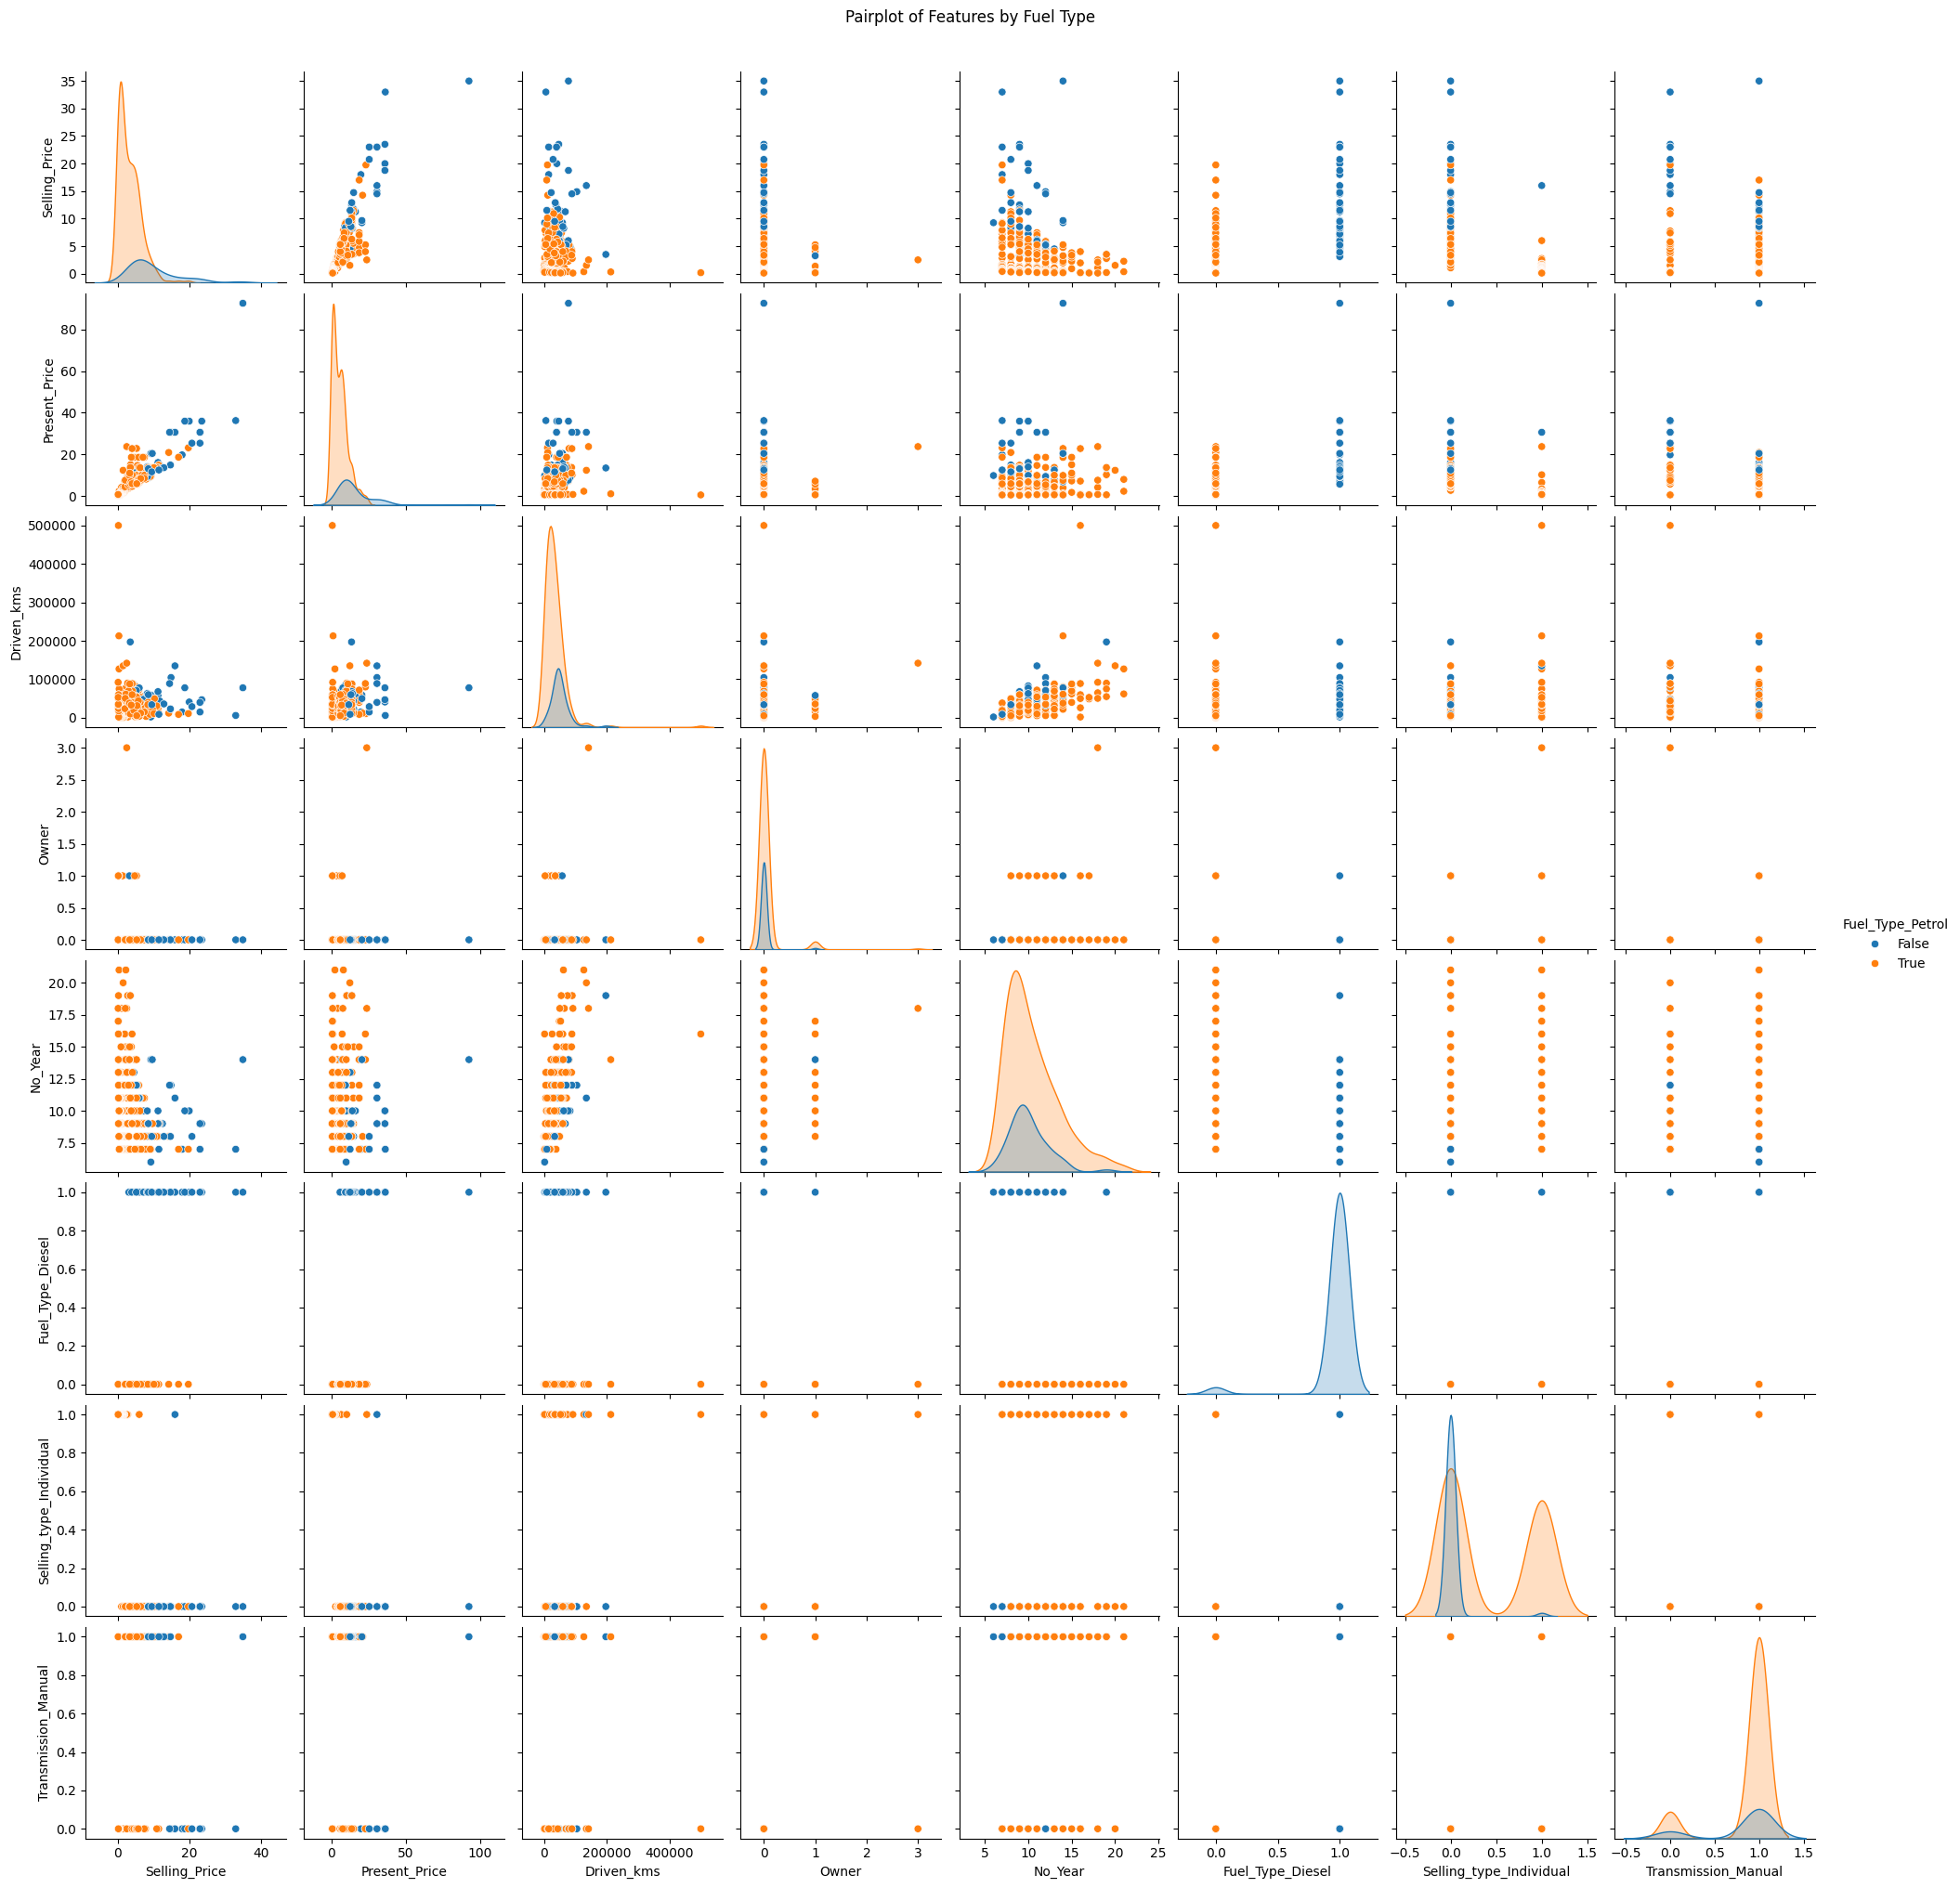

In [ ]:
sns.pairplot(final_data, hue='Fuel_Type_Petrol', diag_kind='kde')
plt.suptitle('Pairplot of Features by Fuel Type', y=1.02) # Adjust suptitle position
plt.show()

##Feature Engineering

In [ ]:
# Log transform highly skewed features (using log1p to handle potential zero values gracefully)
final_data['Selling_Price_log'] = np.log1p(final_data['Selling_Price'])
final_data['Present_Price_log'] = np.log1p(final_data['Present_Price'])

# Create an interaction feature between log-transformed present price and car age
# This can capture how the depreciation based on age interacts with the car's initial value
final_data['Present_Price_log_x_No_Year'] = final_data['Present_Price_log'] * final_data['No_Year']

print("Dataset after additional feature engineering:")
print(final_data.head())
print("\nDescriptive statistics for new features:")
print(final_data[['Selling_Price_log', 'Present_Price_log', 'Present_Price_log_x_No_Year']].describe())

Dataset after additional feature engineering:
   Selling_Price  Present_Price  Driven_kms  Owner  No_Year  Fuel_Type_Diesel  \
0           3.35           5.59       27000      0       10             False   
1           4.75           9.54       43000      0       11              True   
2           7.25           9.85        6900      0        7             False   
3           2.85           4.15        5200      0       13             False   
4           4.60           6.87       42450      0       10              True   

   Fuel_Type_Petrol  Selling_type_Individual  Transmission_Manual  \
0              True                    False                 True   
1             False                    False                 True   
2              True                    False                 True   
3              True                    False                 True   
4             False                    False                 True   

   Selling_Price_log  Present_Price_log  Present_Pri

##Handle Categorical Data

In [ ]:
print('Checking for very rare categories in one-hot encoded features...')

# Identify rows that were originally 'CNG' type based on the one-hot encoded columns
# These are rows where both 'Fuel_Type_Diesel' and 'Fuel_Type_Petrol' are False
cng_indices = final_data[(final_data['Fuel_Type_Diesel'] == False) & (final_data['Fuel_Type_Petrol'] == False)].index

if not cng_indices.empty:
    print(f"Identified {len(cng_indices)} cars originally with 'CNG' fuel type.")
    print("Due to extreme rarity (only 2 samples), these will be re-categorized to improve model learning.")
    print("Merging 'CNG' cars into the 'Petrol' category.")

    # Set Fuel_Type_Petrol to True for these cars, effectively categorizing them as Petrol
    final_data.loc[cng_indices, 'Fuel_Type_Petrol'] = True

    print("\nAfter re-categorization, 'CNG' cars are now treated as 'Petrol' cars. The rows are:")
    # Displaying the modified rows to confirm
    print(final_data.loc[cng_indices, ['Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_Price']])
else:
    print("No 'CNG' fuel type cars found after one-hot encoding, or they were already handled.")

print('\nData handling for imbalanced categorical features complete.')

Checking for very rare categories in one-hot encoded features...
Identified 2 cars originally with 'CNG' fuel type.
Due to extreme rarity (only 2 samples), these will be re-categorized to improve model learning.
Merging 'CNG' cars into the 'Petrol' category.

After re-categorization, 'CNG' cars are now treated as 'Petrol' cars. The rows are:
    Fuel_Type_Diesel  Fuel_Type_Petrol  Selling_Price
18             False              True           3.25
35             False              True           2.95

Data handling for imbalanced categorical features complete.


##Define Features and Target

In [ ]:
X = final_data.drop(['Selling_Price', 'Selling_Price_log', 'Present_Price'], axis=1)
y = final_data['Selling_Price_log']

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
   Driven_kms  Owner  No_Year  Fuel_Type_Diesel  Fuel_Type_Petrol  \
0       27000      0       10             False              True   
1       43000      0       11              True             False   
2        6900      0        7             False              True   
3        5200      0       13             False              True   
4       42450      0       10              True             False   

   Selling_type_Individual  Transmission_Manual  Present_Price_log  \
0                    False                 True           1.885553   
1                    False                 True           2.355178   
2                    False                 True           2.384165   
3                    False                 True           1.638997   
4                    False                 True           2.063058   

   Present_Price_log_x_No_Year  
0                    18.855533  
1                    25.906953  
2                    16.689156  
3            

## Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (240, 9)
X_test shape: (61, 9)
y_train shape: (240,)
y_test shape: (61,)


##Feature Scaling

In [ ]:
# Identify numerical columns for scaling
# Exclude binary (boolean) columns which usually don't need scaling
numerical_cols = X_train.select_dtypes(include=np.number).columns

scaler = StandardScaler()

# Fit on X_train and transform both X_train and X_test
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("X_train after scaling (head):")
print(X_train.head())
print("\nX_test after scaling (head):")
print(X_test.head())

X_train after scaling (head):
     Driven_kms     Owner   No_Year  Fuel_Type_Diesel  Fuel_Type_Petrol  \
184   -0.275555  3.528211  1.969861             False              True   
132   -0.814282 -0.185695 -1.156443             False              True   
194    0.299088 -0.185695  1.969861             False              True   
75    -0.036120 -0.185695 -0.461709             False              True   
111   -0.689776 -0.185695 -0.809076             False              True   

     Selling_type_Individual  Transmission_Manual  Present_Price_log  \
184                     True                 True          -1.325872   
132                     True                 True          -1.205347   
194                     True                 True          -1.302569   
75                     False                 True           0.338671   
111                     True                 True          -0.928617   

     Present_Price_log_x_No_Year  
184                    -0.829615  
132             

##Training First Model — Linear Regression

In [ ]:
# Initialize and train the Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


##Traning other Models

In [ ]:
# Decision Tree Regressor
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_train)
print("Decision Tree Regressor trained successfully!")

# Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train, y_train)
print("Random Forest Regressor trained successfully!")

# Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train, y_train)
print("Gradient Boosting Regressor trained successfully!")

Decision Tree Regressor trained successfully!
Random Forest Regressor trained successfully!
Gradient Boosting Regressor trained successfully!


##Training KNN Model

In [ ]:
# K-Nearest Neighbors Regressor
knn_reg = KNeighborsRegressor()
knn_reg.fit(X_train, y_train)
print("K-Nearest Neighbors Regressor trained successfully!")

K-Nearest Neighbors Regressor trained successfully!


##Training XGBoost, LightGBM and CatBoost Models

In [ ]:
# XGBoost Regressor
xgb_reg = xgb.XGBRegressor(random_state=42)
xgb_reg.fit(X_train, y_train)
print("XGBoost Regressor trained successfully!")

# LightGBM Regressor
lgb_reg = lgb.LGBMRegressor(random_state=42)
lgb_reg.fit(X_train, y_train)
print("LightGBM Regressor trained successfully!")

# CatBoost Regressor
# CatBoost often handles categorical features automatically, but since we've already one-hot encoded, it will treat them as numerical.
cbr_reg = CatBoostRegressor(random_state=42, verbose=0) # verbose=0 to suppress training output
cbr_reg.fit(X_train, y_train)
print("CatBoost Regressor trained successfully!")

XGBoost Regressor trained successfully!
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000155 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 229
[LightGBM] [Info] Number of data points in the train set: 240, number of used features: 8
[LightGBM] [Info] Start training from score 1.403011
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

##Hyperparameter Tuning

In [ ]:
# Define models to tune based on previous performance (CatBoost, LightGBM, Random Forest, XGBoost)
# Linear Regression and KNN are generally less complex in terms of hyperparameter tuning for performance gains

models_to_tune = {
    'CatBoostRegressor': CatBoostRegressor(random_state=42, verbose=0),
    'LightGBMRegressor': lgb.LGBMRegressor(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'XGBoostRegressor': xgb.XGBRegressor(random_state=42)
}

param_grids = {
    'CatBoostRegressor': {
        'iterations': [100, 200, 300],
        'learning_rate': [0.03, 0.1],
        'depth': [4, 6, 8]
    },
    'LightGBMRegressor': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.03, 0.1],
        'num_leaves': [20, 31, 40]
    },
    'RandomForestRegressor': {
        'n_estimators': [100, 200, 300],
        'max_features': ['sqrt', 'log2'],
        'min_samples_split': [2, 5]
    },
    'XGBoostRegressor': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.03, 0.1],
        'max_depth': [3, 5, 7]
    }
}

best_models = {}
for model_name, model in models_to_tune.items():
    print(f"\n--- Tuning {model_name} ---")
    grid_search = GridSearchCV(estimator=model, param_grid=param_grids[model_name],
                               cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)

    best_models[model_name] = grid_search.best_estimator_

    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best negative MSE for {model_name}: {grid_search.best_score_:.4f}")

    # Evaluate on test set with the best estimator
    y_pred_tuned = grid_search.best_estimator_.predict(X_test)
    rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
    r2_tuned = r2_score(y_test, y_pred_tuned)
    print(f"Test RMSE for tuned {model_name}: {rmse_tuned:.4f}")
    print(f"Test R2 Score for tuned {model_name}: {r2_tuned:.4f}")

print("\nHyperparameter tuning complete for selected models.")


--- Tuning CatBoostRegressor ---
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters for CatBoostRegressor: {'depth': 4, 'iterations': 200, 'learning_rate': 0.1}
Best negative MSE for CatBoostRegressor: -0.0220
Test RMSE for tuned CatBoostRegressor: 0.1096
Test R2 Score for tuned CatBoostRegressor: 0.9803

--- Tuning LightGBMRegressor ---
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 229
[LightGBM] [Info] Number of data points in the train set: 240, number of used features: 8
[LightGBM] [Info] Start training from score 1.403011
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

##Making Predictions

In [39]:
tuned_predictions = {}
for model_name, model in best_models.items():
    tuned_predictions[model_name] = model.predict(X_test)
    print(f"Predictions made for {model_name}")

# Optional: Display a sample of predictions for one of the models
print(f"\nSample predictions for CatBoostRegressor:\n{tuned_predictions['CatBoostRegressor'][:5]}")

Predictions made for CatBoostRegressor
Predictions made for LightGBMRegressor
Predictions made for RandomForestRegressor
Predictions made for XGBoostRegressor

Sample predictions for CatBoostRegressor:
[0.35279551 2.47111867 1.79017461 0.19898194 2.0926421 ]


##Evaluate Model Performance


In [42]:
print("\nOverall Performance of Tuned Models on Test Set:")
print(tuned_results_df.sort_values(by='R2 Score', ascending=False))

print(f"\nThe best performing model based on R2 Score is: {best_tuned_model_name}")


Overall Performance of Tuned Models on Test Set:
                   Model       MAE       MSE      RMSE  R2 Score
0      CatBoostRegressor  0.082980  0.012002  0.109556  0.980344
1      LightGBMRegressor  0.088950  0.014245  0.119351  0.976673
3       XGBoostRegressor  0.089191  0.015241  0.123456  0.975040
2  RandomForestRegressor  0.083228  0.016506  0.128475  0.972969

The best performing model based on R2 Score is: CatBoostRegressor



Performance of Tuned Models on Test Set:
                   Model       MAE       MSE      RMSE  R2 Score
0      CatBoostRegressor  0.082980  0.012002  0.109556  0.980344
1      LightGBMRegressor  0.088950  0.014245  0.119351  0.976673
3       XGBoostRegressor  0.089191  0.015241  0.123456  0.975040
2  RandomForestRegressor  0.083228  0.016506  0.128475  0.972969


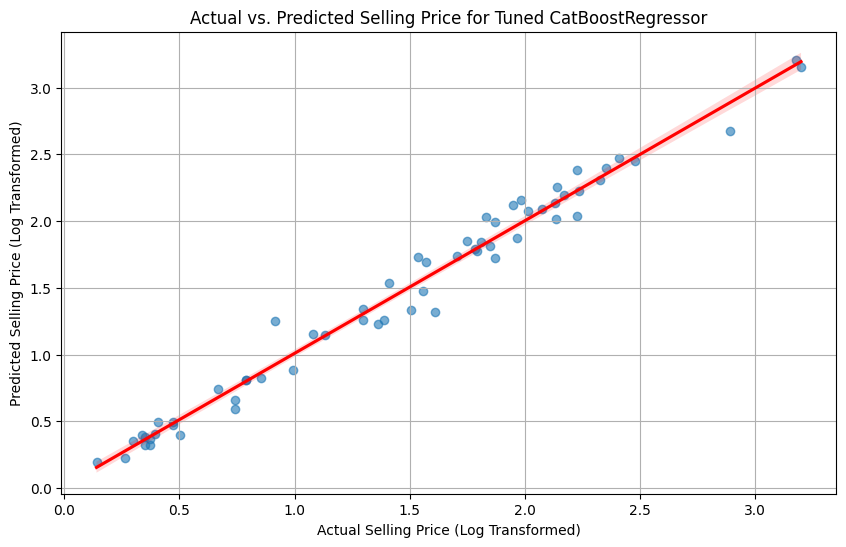

In [40]:
tuned_results = []

for model_name, y_pred_tuned in tuned_predictions.items():
    # Convert predictions back from log scale if necessary, though evaluation on log scale is often fine
    # For direct comparison with y_test (which is also log-transformed), we evaluate y_pred_tuned directly.

    mae = mean_absolute_error(y_test, y_pred_tuned)
    mse = mean_squared_error(y_test, y_pred_tuned)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_tuned)

    tuned_results.append({
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

tuned_results_df = pd.DataFrame(tuned_results)

print("\nPerformance of Tuned Models on Test Set:")
print(tuned_results_df.sort_values(by='R2 Score', ascending=False))

# Optional: Visualize predictions vs. actuals for the best performing tuned model
# Find the best model based on R2 score
best_tuned_model_name = tuned_results_df.loc[tuned_results_df['R2 Score'].idxmax()]['Model']
best_tuned_predictions = tuned_predictions[best_tuned_model_name]

plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=best_tuned_predictions, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('Actual Selling Price (Log Transformed)')
plt.ylabel('Predicted Selling Price (Log Transformed)')
plt.title(f'Actual vs. Predicted Selling Price for Tuned {best_tuned_model_name}')
plt.grid(True)
plt.show()

### Understanding Evaluation Metrics

*   **Mean Absolute Error (MAE):** This is the average of the absolute differences between the predicted and actual values. It gives an idea of the magnitude of errors in the predictions. A lower MAE indicates a more accurate model.

*   **Mean Squared Error (MSE):** This is the average of the squared differences between the predicted and actual values. It penalizes larger errors more heavily than MAE. Like MAE, a lower MSE indicates better performance.

*   **Root Mean Squared Error (RMSE):** This is the square root of the MSE. It's often preferred because it's in the same units as the target variable, making it easier to interpret. A lower RMSE is better.

*   **R-squared (R2 Score):** This metric represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 score of 1 indicates that the model perfectly predicts the target variable, while a score of 0 means the model explains none of the variance. Higher R2 scores are generally better.

##Feature Importance

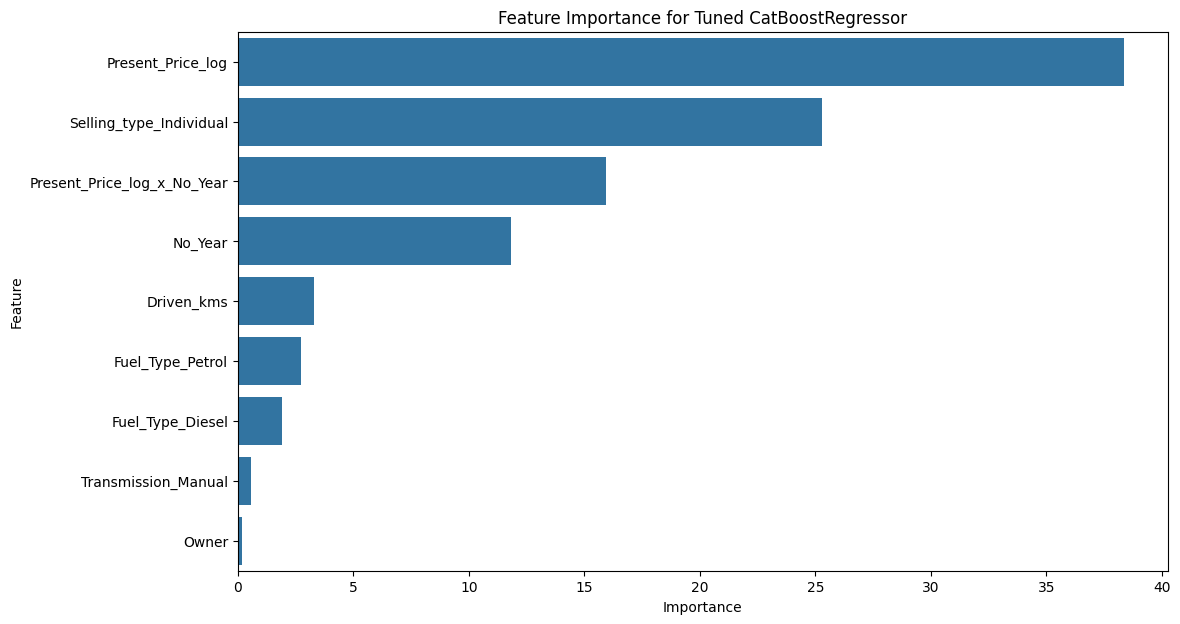


Top 5 Most Important Features for CatBoostRegressor:
                       Feature  Importance
7            Present_Price_log   38.343666
5      Selling_type_Individual   25.270105
8  Present_Price_log_x_No_Year   15.924489
2                      No_Year   11.820387
0                   Driven_kms    3.292617


In [41]:
importances = best_models[best_tuned_model_name].get_feature_importance()
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title(f'Feature Importance for Tuned {best_tuned_model_name}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print(f"\nTop 5 Most Important Features for {best_tuned_model_name}:")
print(feature_importance_df.head())

##Saving the Trained Model

In [44]:
# Get the best performing model
best_model_to_save = best_models[best_tuned_model_name]

# Define a filename for the saved model
model_filename = 'best_car_price_prediction_model.joblib'

# Save the model to a file
joblib.dump(best_model_to_save, model_filename)

print(f"Best model ({best_tuned_model_name}) saved successfully to {model_filename}")

Best model (CatBoostRegressor) saved successfully to best_car_price_prediction_model.joblib


##Predicting New Car Price

In [45]:
# Load the saved model
loaded_model = joblib.load('best_car_price_prediction_model.joblib')
print(f"Model '{loaded_model.__class__.__name__}' loaded successfully.")

# Define a sample new car data for prediction
# This should mimic the features of X_train/X_test
# Values are hypothetical, adjust as needed
new_car_data = {
    'Driven_kms': [50000],  # Example: 50,000 km driven
    'Owner': [0],          # Example: First owner
    'No_Year': [5],        # Example: 5 years old (current_year - Year)
    'Fuel_Type_Diesel': [False],
    'Fuel_Type_Petrol': [True], # Example: Petrol car
    'Selling_type_Individual': [False], # Example: Sold by dealer
    'Transmission_Manual': [True],  # Example: Manual transmission
    'Present_Price_log': [np.log1p(7.0)], # Example: Present price 7.0 lakhs (log-transformed)
    # The interaction term is calculated from the new 'Present_Price_log' and 'No_Year'
    'Present_Price_log_x_No_Year': [np.log1p(7.0) * 5]
}

# Create a DataFrame for the new car data
new_car_df = pd.DataFrame(new_car_data)

# Ensure column order matches X_train/X_test
# We'll use X_train's columns as reference
new_car_df = new_car_df[X_train.columns]

# Scale numerical features using the *same scaler* fitted on the training data
# Make sure 'scaler' object is available from previous execution if running cells out of order
numerical_cols = new_car_df.select_dtypes(include=np.number).columns
new_car_df[numerical_cols] = scaler.transform(new_car_df[numerical_cols])

print("\nPreprocessed new car data:")
print(new_car_df)

# Make prediction
predicted_log_price = loaded_model.predict(new_car_df)

# Inverse transform the log-predicted price to get the actual selling price
predicted_selling_price = np.expm1(predicted_log_price)

print(f"\nPredicted Selling Price for the new car: {predicted_selling_price[0]:.2f} Lakhs")

Model 'CatBoostRegressor' loaded successfully.

Preprocessed new car data:
   Driven_kms     Owner   No_Year  Fuel_Type_Diesel  Fuel_Type_Petrol  \
0    0.299088 -0.185695 -1.851177             False              True   

   Selling_type_Individual  Transmission_Manual  Present_Price_log  \
0                    False                 True            0.36687   

   Present_Price_log_x_No_Year  
0                    -0.696968  

Predicted Selling Price for the new car: 4.40 Lakhs
